<a href="https://colab.research.google.com/github/Mukundan-T/seqADAGE/blob/master/Py/muk_transfer_learning/genomic_mapping/Mukundan_sA_ec_pg_mapping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# E. coli &rightarrow; S. aureus Gene Mapping

### Mukundan Thanigaivelan

#### July 9, 2026

Here we are trying to map E. coli genes to S. aureus genes using techniques such as BLAST, k-mer mapping, and AlphaFold.

## 1. Connect to GitHub

In [1]:
!git clone https://github.com/Mukundan-T/seqADAGE.git

fatal: destination path 'seqADAGE' already exists and is not an empty directory.


In [2]:
%cd seqADAGE/Py/muk_transfer_learning/genomic_mapping

/content/seqADAGE/Py/muk_transfer_learning/genomic_mapping


In [3]:
!pip install -qq biopython

## 2. Loading classes & modules

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

In [11]:
# Data Analysis
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Miscellaneous
import time
import tensorflow as tf

In [12]:
# check CPU and GPU available in runtime
print("Num CPUs Available: ", len(tf.config.list_physical_devices('CPU')))
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print(tf.test.is_built_with_cuda())

Num CPUs Available:  1
Num GPUs Available:  1
True


## 3. BLAST

### Installation

In [15]:
!apt-get -qq update
!apt-get -qq install ncbi-blast+

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package ncbi-data.
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack .../ncbi-data_6.1.20170106+dfsg1-9_all.deb ...
Unpacking ncbi-data (6.1.20170106+dfsg1-9) ...
Selecting previously unselected package ncbi-blast+.
Preparing to unpack .../ncbi-blast+_2.12.0+ds-3build1_amd64.deb ...
Unpacking ncbi-blast+ (2.12.0+ds-3build1) ...
Setting up ncbi-data (6.1.20170106+dfsg1-9) ...
Setting up ncbi-blast+ (2.12.0+ds-3build1) ...
Processing triggers for man-db (2.10.2-1) ...
Processing triggers for hicolor-icon-theme (0.17-2) ...


In [16]:
!blastn -version

blastn: 2.12.0+
 Package: blast 2.12.0, build Mar  8 2022 16:19:08


### Make BLAST database

In [23]:
ec_fasta = '/content/drive/MyDrive/Comp-Bio-Projs-S26/data/muk-in-use/ec_pan_genome_reference.fa'
sa_fasta = '/content/drive/MyDrive/Comp-Bio-Projs-S26/data/muk-in-use/sa_pan_genome_reference.fa'

In [24]:
!makeblastdb -in "{ec_fasta}" -dbtype nucl -out ecoli_db



Building a new DB, current time: 07/10/2026 14:49:17
New DB name:   /content/seqADAGE/Py/muk_transfer_learning/genomic_mapping/ecoli_db
New DB title:  /content/drive/MyDrive/Comp-Bio-Projs-S26/data/muk-in-use/ec_pan_genome_reference.fa
Sequence type: Nucleotide
Keep MBits: T
Maximum file size: 1000000000B
Adding sequences from FASTA; added 68546 sequences in 3.00472 seconds.




### Blast S. aureus genes against database and save hits

In [37]:
blast_hits_file = '/content/drive/My Drive/Comp-Bio-Projs-S26/data/muk-in-use/blast_hits.tsv'

In [38]:
!blastn \
  -query "{sa_fasta}" \
  -db ecoli_db \
  -out "{blast_hits_file}" \
  -outfmt 6

In [40]:
columns = [
  "query", "subject", "pident", "length",
  "mismatch", "gapopen", "qstart", "qend",
  "sstart", "send", "evalue", "bitscore"
]

hits = pd.read_csv(blast_hits_file, sep = "\t", names = columns)
hits.shape

(7312, 12)

### Inspect and filter for best hits

In [41]:
hits.head()

,query,subject,pident,length,mismatch,gapopen,qstart,qend,sstart,send,evalue,bitscore
0,12b493b74dec297122c11824ed05ba01_3,panDB562_47409,99.780,1362,3,0,1,1362,1,1362,0.0,2499.0
1,12b493b74dec297122c11824ed05ba01_5,panDB562_47408,99.647,1134,4,0,1,1134,1,1134,0.0,2073.0
2,12b493b74dec297122c11824ed05ba01_9,panDB562_47407,99.820,1113,2,0,1,1113,1,1113,0.0,2045.0
3,12b493b74dec297122c11824ed05ba01_11,panDB562_47406,99.845,1935,3,0,1,1935,1,1935,0.0,3557.0
4,12b493b74dec297122c11824ed05ba01_13,panDB562_47405,98.390,2670,43,0,1,2670,1,2670,0.0,4693.0


In [46]:
hits.describe()

,pident,length,mismatch,gapopen,qstart,qend,sstart,send,evalue,bitscore
count,7312.000000,7312.000000,7312.000000,7312.000000,7312.000000,7312.000000,7312.000000,7312.000000,7.312000e+03,7312.000000
mean,97.386560,548.622812,11.576586,0.509847,126.768326,674.059354,216.755607,717.489606,9.927411e-09,945.319283
std,4.403544,524.543432,28.895761,2.625259,1198.731851,1302.197932,425.747971,593.130040,4.479023e-07,940.864001
min,72.301000,28.000000,0.000000,0.000000,1.000000,28.000000,1.000000,1.000000,0.000000e+00,52.800000
25%,97.143000,209.000000,1.000000,0.000000,1.000000,227.750000,1.000000,300.000000,0.000000e+00,344.000000
50%,99.142000,357.000000,3.000000,0.000000,1.000000,402.000000,1.000000,602.000000,4.800000e-166,582.000000
75%,99.822000,759.000000,10.000000,0.000000,1.000000,858.000000,271.000000,975.000000,1.775000e-94,1308.000000
max,100.000000,7176.000000,415.000000,69.000000,31333.000000,31635.000000,7012.000000,7341.000000,3.750000e-05,13075.000000


In [44]:
# Number of unique SA genes represented
hits['query'].nunique()

4356

In [45]:
# Number of unique EC genes represented
hits['subject'].nunique()

5255

In [71]:
# Match each SA gene to its best EC hit
best_hits = hits.loc[hits.groupby("query")["pident"].idxmax()]
best_hits.shape

(4356, 12)

<Axes: xlabel='pident', ylabel='Count'>

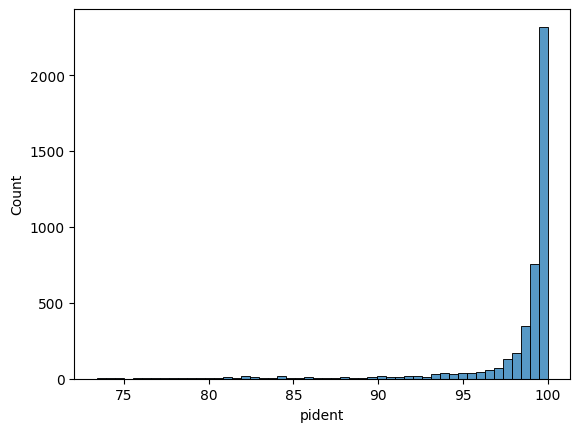

In [73]:
# How are the percentage similarities distributed?
sns.histplot(best_hits['pident'], bins = 50)